In [1]:
%load_ext autoreload
%autoreload 2

In [25]:
import sys
sys.path.append('..')
from firstpassage.FPTCalculator import *
from lo_circuit.fusion_network import *
from lo_circuit.fusion_order import *
from graphtheory.ghz_partitioning import *
import random
import perceval as pcvl
import itertools
import networkx as nx

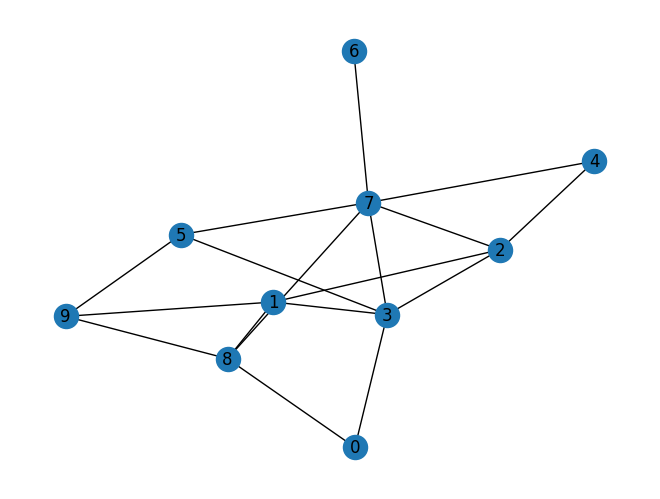

In [3]:
random.seed(1234)
def connect_graph(G):
    C = list(nx.connected_components(G))
    for idx in range(1,len(C)):
        G.add_edge(list(C[idx-1])[0],list(C[idx])[0])

G = nx.erdos_renyi_graph(10, 0.3)
connect_graph(G)
nx.draw(G,with_labels=True)

[[6, 7, 5], [4, 2, 3], [0, 8, 1], [9]]
initial {6: 0, 7: 1, 5: 2, 4: 3, 2: 4, 3: 5, 0: 6, 8: 10, 1: 8, 9: 11}
add edge 1 2
vertexposmap update v1 13 v2 16
add edge 2 7
vertexposmap update v1 19 v2 22
add edge 3 7
vertexposmap update v1 25 v2 28
add edge 0 3
vertexposmap update v1 31 v2 34
add edge 4 7
vertexposmap update v1 37 v2 40
add edge 7 8
vertexposmap update v1 43 v2 46
add edge 5 9
vertexposmap update v1 49 v2 52
add edge 1 3
vertexposmap update v1 55 v2 58
add edge 1 9
vertexposmap update v1 61 v2 64
add edge 3 5
vertexposmap update v1 67 v2 70


[(7, 9),
 (8, 12),
 (14, 15),
 (17, 4),
 (16, 18),
 (20, 21),
 (23, 1),
 (5, 24),
 (26, 27),
 (29, 22),
 (6, 30),
 (32, 33),
 (35, 25),
 (3, 36),
 (38, 39),
 (41, 28),
 (40, 42),
 (44, 45),
 (47, 10),
 (2, 48),
 (50, 51),
 (53, 11),
 (13, 54),
 (56, 57),
 (59, 34),
 (55, 60),
 (62, 63),
 (65, 52),
 (58, 66),
 (68, 69),
 (71, 49)]

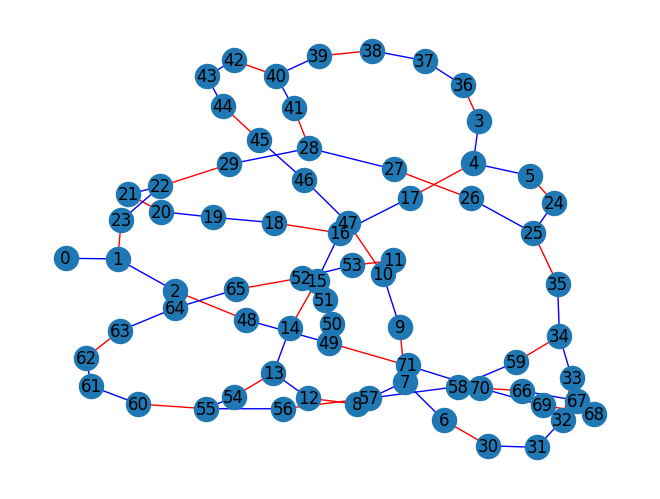

In [21]:
ghz_partitions = ghz_partitioning_heuristic(G)
print(ghz_partitions)
fusion_network = build_fusion_network_from_ghz_partitions(ghz_partitions,G)
draw_fusion_network(fusion_network)
fusion_network
# fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
# draw_contracted_fusion_network(fusion_order)

In [24]:
fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
print(fusion_order)
max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
fpt = get_fp_times(fusion_order, max_qubit, [0.5,0.66,0.75,0.85,1])
fpt

[(62, 63), (1, 23), (3, 36), (32, 33), (16, 18), (50, 51), (8, 12), (68, 69), (40, 42), (26, 27), (10, 47), (56, 57), (25, 35), (38, 39), (7, 9), (49, 71), (20, 21), (55, 60), (2, 48), (13, 54), (5, 24), (28, 41), (4, 17), (22, 29), (14, 15), (6, 30), (44, 45), (11, 53), (34, 59), (52, 65), (58, 66)]


{0.5: 184090.12345114024,
 0.66: 1347.2800458425377,
 0.75: 198.63533212012373,
 0.85: 62.56917994436299,
 1: 30.99999999039205}

[(0, 3),
 (8, 9),
 (11, 4),
 (10, 12),
 (1, 15),
 (5, 18),
 (20, 21),
 (23, 2),
 (17, 24),
 (26, 27),
 (29, 6),
 (14, 30),
 (32, 33),
 (35, 19),
 (34, 36),
 (38, 39),
 (41, 16),
 (25, 42),
 (7, 45),
 (47, 48),
 (50, 40),
 (31, 51),
 (53, 54),
 (56, 28),
 (49, 57),
 (44, 60),
 (62, 63),
 (65, 13),
 (52, 66),
 (68, 69),
 (71, 43)]

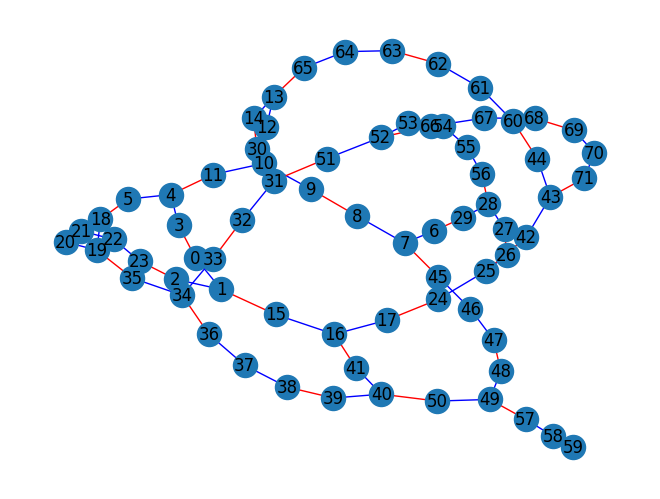

In [27]:
fusion_network = build_fusion_network_random(G)
draw_fusion_network(fusion_network)
fusion_network

In [29]:
fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
print(fusion_order)
max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
fpt = get_fp_times(fusion_order, max_qubit, [0.5,0.66,0.75,0.85,1])
fpt

[(62, 63), (32, 33), (10, 12), (49, 57), (52, 66), (17, 24), (28, 56), (20, 21), (38, 39), (0, 3), (7, 45), (43, 71), (5, 18), (2, 23), (44, 60), (53, 54), (47, 48), (14, 30), (16, 41), (6, 29), (25, 42), (4, 11), (19, 35), (1, 15), (34, 36), (13, 65), (8, 9), (26, 27), (40, 50), (31, 51), (68, 69)]


{0.5: 451939.79994903755,
 0.66: 1262.8686658708473,
 0.75: 192.7490151012532,
 0.85: 64.30855872652076,
 1: 31.000000006929135}

[(0, 3),
 (5, 6),
 (8, 9),
 (11, 2),
 (7, 12),
 (14, 15),
 (17, 18),
 (20, 4),
 (16, 21),
 (10, 24),
 (26, 27),
 (29, 30),
 (32, 13),
 (28, 33),
 (35, 36),
 (38, 39),
 (41, 19),
 (37, 42),
 (44, 45),
 (47, 48),
 (50, 22),
 (46, 51),
 (53, 54),
 (56, 40),
 (52, 57),
 (59, 60),
 (62, 23),
 (58, 63),
 (65, 66),
 (68, 25),
 (64, 69)]

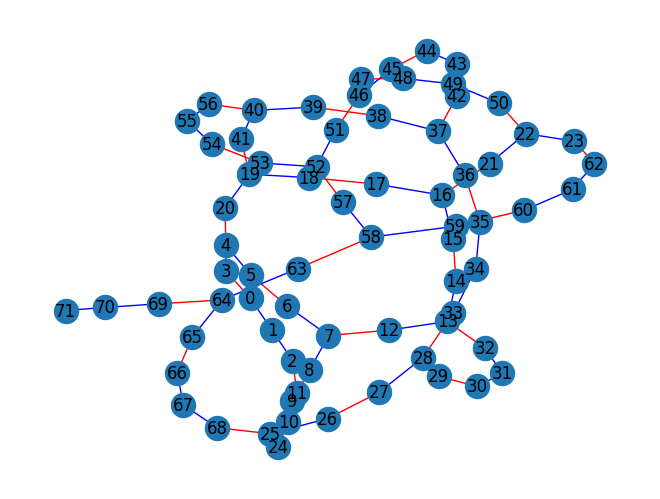

In [30]:
T = get_spanning_tree(G,'dfs','random',True)
fusion_network = build_fusion_network_from_spanning_tree(T,0,G)
draw_fusion_network(fusion_network)
fusion_network

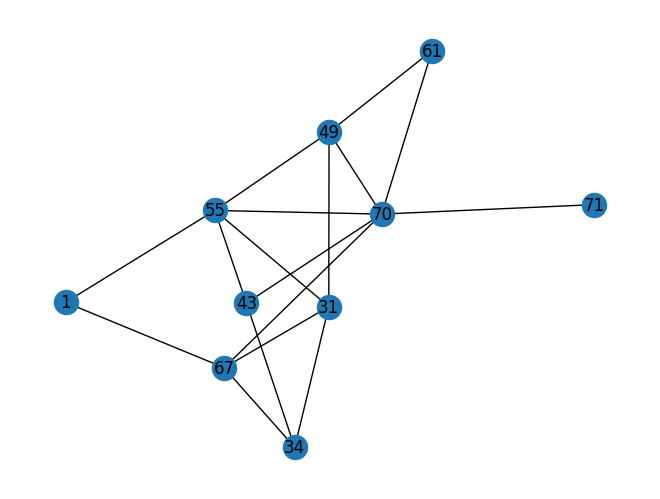

In [169]:
T = get_spanning_tree(G,'dfs','random',True)
fusion_network = build_fusion_network_from_spanning_tree(T,0,G)
fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
draw_contracted_fusion_network(fusion_order)

In [170]:
for conf in itertools.product(['dfs','bfs'],['random','min','max'],[True,False]):
    T = get_spanning_tree(G,conf[0],conf[1],conf[2])
    fusion_network = build_fusion_network_from_spanning_tree(T,0,G)
    fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
    max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
    fpt = get_fp_times(fusion_order, max_qubit, [0.5,0.66,0.75,0.85,1])
    print(conf,":",fpt)

('dfs', 'random', True) : {0.5: 466439.0371615931, 0.66: 1681.4575635947303, 0.75: 180.2685353922838, 0.85: 60.639489693909226, 1: 30.99999999576604}
('dfs', 'random', False) : {0.5: 294249.5820244504, 0.66: 1031.443019741992, 0.75: 154.94081414034073, 0.85: 56.79414733020059, 1: 31.000000000243535}
('dfs', 'min', True) : {0.5: 345638.6402546859, 0.66: 1439.6523723508876, 0.75: 174.6682257872103, 0.85: 58.565307988192835, 1: 31.000000006655824}
('dfs', 'min', False) : {0.5: 960591.8428529502, 0.66: 1600.4450938043744, 0.75: 181.8396560068586, 0.85: 58.70317657432822, 1: 30.999999993187892}
('dfs', 'max', True) : {0.5: 466439.0371615931, 0.66: 1681.4575635947303, 0.75: 180.2685353922838, 0.85: 60.639489693909226, 1: 30.99999999576604}
('dfs', 'max', False) : {0.5: 294249.5820244504, 0.66: 1031.443019741992, 0.75: 154.94081414034073, 0.85: 56.79414733020059, 1: 31.000000000243535}
('bfs', 'random', True) : {0.5: 493893.49631633586, 0.66: 1388.517524473032, 0.75: 185.5625634642555, 0.85: 

In [8]:
for conf in itertools.product(['dfs','bfs'],['random','min','max'],[True,False]):
    T = get_spanning_tree(G,conf[0],conf[1],conf[2])
    max_deg_vertex = sorted([(G.degree(v),v) for v in G.nodes])[-1][1]
    fusion_network = build_fusion_network_from_spanning_tree(T,max_deg_vertex,G)
    fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
    max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
    fpt = get_fp_times(fusion_order, max_qubit, [0.5,0.66,0.75,0.85,1])
    print(conf,":",fpt)

('dfs', 'random', True) : {0.5: 552240.6142186358, 0.66: 1535.5443381233852, 0.75: 194.15162912744728, 0.85: 60.1539328510803, 1: 31.000000023077515}
('dfs', 'random', False) : {0.5: 613667.6638693516, 0.66: 1210.6929934467603, 0.75: 153.12839648250733, 0.85: 57.70885422248112, 1: 31.00000001638608}
('dfs', 'min', True) : {0.5: 173968.28306458305, 0.66: 1189.7088329260423, 0.75: 182.1461469719633, 0.85: 60.1396338494147, 1: 30.999999999863228}
('dfs', 'min', False) : {0.5: 166617.88101519816, 0.66: 1187.5556693963479, 0.75: 184.39476832528186, 0.85: 60.68793777265451, 1: 31.00000000489955}
('dfs', 'max', True) : {0.5: 552240.6142186358, 0.66: 1535.5443381233852, 0.75: 194.15162912744728, 0.85: 60.1539328510803, 1: 31.000000023077515}
('dfs', 'max', False) : {0.5: 613667.6638693516, 0.66: 1210.6929934467603, 0.75: 153.12839648250733, 0.85: 57.70885422248112, 1: 31.00000001638608}
('bfs', 'random', True) : {0.5: 636379.0948445771, 0.66: 1275.9666931804968, 0.75: 162.95310992329988, 0.85:

In [9]:
for conf in itertools.product(['dfs','bfs'],['random','min','max'],[True,False]):
    T = get_spanning_tree(G,conf[0],conf[1],conf[2])
    min_deg_vertex = sorted([(G.degree(v),v) for v in G.nodes])[0][1]
    fusion_network = build_fusion_network_from_spanning_tree(T,min_deg_vertex,G)
    fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
    max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
    fpt = get_fp_times(fusion_order, max_qubit, [0.5,0.66,0.75,0.85,1])
    print(conf,":",fpt)

('dfs', 'random', True) : {0.5: 552240.6142186358, 0.66: 1535.5443381233852, 0.75: 194.15162912744728, 0.85: 60.1539328510803, 1: 31.000000023077515}
('dfs', 'random', False) : {0.5: 204656.82187673857, 0.66: 1082.9127972821987, 0.75: 170.54671632986546, 0.85: 58.19182177022208, 1: 30.99999998123256}
('dfs', 'min', True) : {0.5: 173968.28306458305, 0.66: 1189.7088329260423, 0.75: 182.1461469719633, 0.85: 60.1396338494147, 1: 30.999999999863228}
('dfs', 'min', False) : {0.5: 1331392.20465561, 0.66: 1710.198113665476, 0.75: 174.8498064704983, 0.85: 57.05241853695601, 1: 30.999999986753927}
('dfs', 'max', True) : {0.5: 552240.6142186358, 0.66: 1535.5443381233852, 0.75: 194.15162912744728, 0.85: 60.1539328510803, 1: 31.000000023077515}
('dfs', 'max', False) : {0.5: 204656.82187673857, 0.66: 1082.9127972821987, 0.75: 170.54671632986546, 0.85: 58.19182177022208, 1: 30.99999998123256}
('bfs', 'random', True) : {0.5: 636379.0948445771, 0.66: 1275.9666931804968, 0.75: 162.95310992329988, 0.85: 

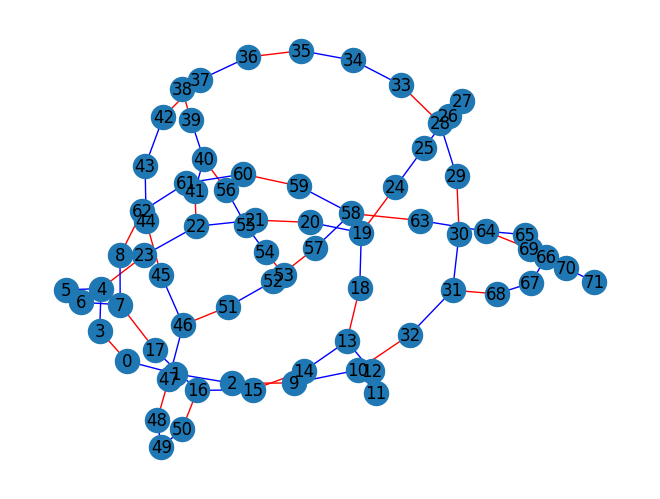

In [176]:
T = get_spanning_tree(G,'dfs', 'min', True)
# nx.draw(T, with_labels=True)
fusion_network = build_fusion_network_from_spanning_tree(T,0,G)
network_graph = draw_fusion_network(fusion_network)

In [179]:
sum([network_graph.degree[v] for v in network_graph.nodes])

158

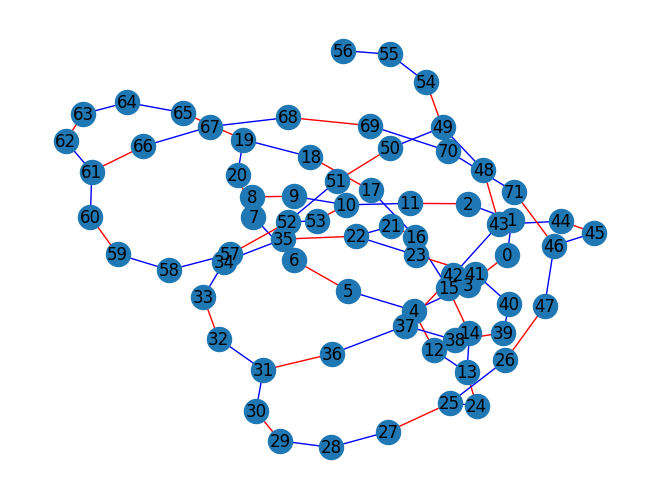

In [183]:
T = get_spanning_tree(G,'bfs', 'max', False)
# nx.draw(T, with_labels=True)
fusion_network = build_fusion_network_from_spanning_tree(T,0,G)
network_graph2 = draw_fusion_network(fusion_network)

In [184]:
nx.is_isomorphic(network_graph,network_graph2)

False

In [185]:
sum([network_graph2.degree[v] for v in network_graph2.nodes])

158

In [106]:
T = get_spanning_tree(G)
fusion_network = build_fusion_network_from_spanning_tree(T,0,G)
fusion_network

[(2, 3),
 (5, 6),
 (8, 9),
 (11, 12),
 (14, 0),
 (7, 15),
 (17, 18),
 (20, 21),
 (23, 24),
 (26, 27),
 (29, 13),
 (22, 30),
 (32, 33),
 (35, 36),
 (38, 28),
 (19, 39)]

In [107]:
fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
fusion_order

[(11, 12),
 (22, 30),
 (26, 27),
 (19, 39),
 (2, 3),
 (35, 36),
 (7, 15),
 (32, 33),
 (13, 29),
 (17, 18),
 (5, 6),
 (23, 24),
 (28, 38),
 (8, 9),
 (0, 14),
 (20, 21)]

In [108]:
max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
get_fp_times(fusion_order, max_qubit, [0.5,0.66,0.75,0.85,1])

{0.5: 734.3429321595827,
 0.66: 85.62493459749192,
 0.75: 41.272153447888776,
 0.85: 25.010308433559967,
 1: 15.999999983134689}

In [109]:
random.shuffle(fusion_order)
max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
get_fp_times(fusion_order, max_qubit, [0.5,0.66,0.75,0.85,1])

{0.5: 1723.560521079879,
 0.66: 100.23227614833282,
 0.75: 43.72109324163026,
 0.85: 25.525690170547588,
 1: 16.00000001660112}

In [63]:
fusion_order

[(26, 27),
 (31, 45),
 (28, 33),
 (40, 42),
 (20, 21),
 (16, 38),
 (0, 14),
 (19, 24),
 (4, 39),
 (29, 30),
 (5, 6),
 (10, 15),
 (1, 23),
 (11, 12),
 (35, 36),
 (2, 3),
 (22, 32),
 (17, 18),
 (8, 9)]